# General Prediction Evaluations

Given chemprop results, calculates the required metrics for regression and classification tasks.

In [1]:
from collections import defaultdict
import json
import os
import glob
from typing import List, Callable, Union

import numpy as np
import pandas as pd
from sklearn.metrics import (average_precision_score, mean_absolute_error, root_mean_squared_error,
                             precision_recall_curve, r2_score, roc_auc_score, mean_absolute_percentage_error, auc)
%load_ext autoreload
%autoreload 2

from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from chemprop import models

In [2]:
def parse_indices(idxs):
    """Parses a string of indices into a list of integers. e.g. '0,1,2-4' -> [0, 1, 2, 3, 4]"""
    if isinstance(idxs, str):
        indices = []
        for idx in idxs.split(","):
            if "-" in idx:
                start, end = map(int, idx.split("-"))
                indices.extend(range(start, end + 1))
            else:
                indices.append(int(idx))
        return indices
    return idxs

def prc_auc(targets: List[int], preds: List[float]) -> float:
    """
    Computes the area under the precision-recall curve.

    :param targets: A list of binary targets.
    :param preds: A list of prediction probabilities.
    :return: The computed prc-auc.
    """
    precision, recall, _ = precision_recall_curve(targets, preds)
    return auc(recall, precision)

def get_metric_func(metric: str):
    r"""
    Gets the metric function corresponding to a given metric name.

    Supports:

    * :code:`roc-auc`: Area under the receiver operating characteristic curve
    * :code:`prc-auc`: Area under the precision recall curve
    * :code:`ap`: Average precision from prediction scores
    * :code:`rmse`: Root mean squared error
    * :code:`mae`: Mean absolute error
    * :code:`r2`: Coefficient of determination R\ :superscript:`2`

    :param metric: Metric name.
    :return: A metric function which takes as arguments a list of targets and a list of predictions and returns.
    """
    if metric == 'roc-auc':
        return roc_auc_score

    if metric == 'prc-auc':
        return prc_auc
    
    if metric == 'ap':
        return average_precision_score

    if metric == 'rmse':
        return root_mean_squared_error
    
    if metric == 'mae':
        return mean_absolute_error

    if metric == 'r2':
        return r2_score
    
    raise ValueError(f'Metric "{metric}" not supported.')
    

In [3]:
def evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=None):
    df = pd.read_csv(data_path)
    with open(splits_path, "rb") as json_file:
        split_idxss = json.load(json_file)
    test_indices = [parse_indices(d["test"]) for d in split_idxss]
    test_df = df.iloc[test_indices[0]]
    target_columns=test_df.keys()[-num_tasks:].tolist() if target_columns is None else target_columns

    df_pred_list = []
    files = glob.glob(os.path.join(result_dir, '**', "test_predictions.csv"), recursive=True)
    assert len(files) == 5, f"There should be 5 files; {len(files)} found"
    for file in files:
        df_pred = pd.read_csv(file)[target_columns]
        df_pred_list.append(df_pred)
    df_pred = pd.concat(df_pred_list).groupby(level=0).mean()

    metric_to_func = {metric: get_metric_func(metric) for metric in metrics}

    results = defaultdict(list)
    for column in target_columns:
        for metric, metric_func in metric_to_func.items():
            preds = df_pred[column].tolist()
            targets = test_df[column].tolist()
            results[metric].append(metric_func(targets, preds))
    results = dict(results)

    results_df = pd.DataFrame(results, index=target_columns)
    return results_df

In [4]:
import pandas as pd
import numpy as np
import os
import glob
import json
from collections import defaultdict

def evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=None):
    # Load data and test split
    df = pd.read_csv(data_path)
    with open(splits_path, "rb") as json_file:
        split_idxss = json.load(json_file)
    test_indices = [parse_indices(d["test"]) for d in split_idxss]
    test_df = df.iloc[test_indices[0]]
    
    # Determine target columns
    target_columns = test_df.keys()[-num_tasks:].tolist() if target_columns is None else target_columns

    # Gather prediction files
    files = glob.glob(os.path.join(result_dir, '**', "test_predictions.csv"), recursive=True)
    assert len(files) == 5, f"There should be 5 files; {len(files)} found"

    # Create a dictionary to store results for each file
    results = defaultdict(lambda: defaultdict(list))  # Format: results[file][metric] = [metric values for each target]
    
    # Map metric names to their respective functions
    metric_to_func = {metric: get_metric_func(metric) for metric in metrics}

    # Process each prediction file individually
    for file in files:
        df_pred = pd.read_csv(file)[target_columns]

        # For each target column and metric, calculate metrics for the current file
        for column in target_columns:
            preds = df_pred[column].tolist()
            targets = test_df[column].tolist()
            for metric, metric_func in metric_to_func.items():
                metric_value = metric_func(targets, preds)
                results[file][metric].append(metric_value)  # Store the metric value for this file

    # Create a dictionary to store aggregated results
    aggregated_results = defaultdict(dict)

    # Calculate average and standard deviation for each metric across files
    for metric in metrics:
        metric_values = []

        # Gather all metric values for this metric across files
        for file in files:
            metric_values.append(results[file][metric])

        # Convert to a numpy array for easier mean and std calculations
        metric_values = np.array(metric_values)

        # Store mean and std
        aggregated_results[metric]["mean"] = np.mean(metric_values, axis=0)
        aggregated_results[metric]["std"] = np.std(metric_values, axis=0)

    # Convert results to DataFrame format
    individual_results_df = pd.DataFrame(results)
    aggregated_results_df = pd.DataFrame(aggregated_results)

    return aggregated_results_df

In [5]:
def evaluate_results_1(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=None):
    df = pd.read_csv(data_path)
    with open(splits_path, "rb") as json_file:
        split_idxss = json.load(json_file)
    test_indices = [parse_indices(d["test"]) for d in split_idxss]
    test_df = df.iloc[test_indices[0]]
    target_columns=test_df.keys()[-num_tasks:].tolist() if target_columns is None else target_columns

    df_pred_list = []
    files = glob.glob(os.path.join(result_dir, '**', "test_predictions.csv"), recursive=True)
    # assert len(files) == 5, f"There should be 5 files; {len(files)} found"
    for file in files:
        df_pred = pd.read_csv(file)[target_columns]
        df_pred_list.append(df_pred)
    df_pred = pd.concat(df_pred_list).groupby(level=0).mean()

    metric_to_func = {metric: get_metric_func(metric) for metric in metrics}

    results = defaultdict(list)
    for column in target_columns:
        for metric, metric_func in metric_to_func.items():
            preds = df_pred[column].tolist()
            targets = test_df[column].tolist()
            results[metric].append(metric_func(targets, preds))
    results = dict(results)

    results_df = pd.DataFrame(results, index=target_columns)
    return results_df

In [6]:
def evaluate_results_full(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=None, model_path=None):
    df = pd.read_csv(data_path)
    with open(splits_path, "rb") as json_file:
        split_idxss = json.load(json_file)
    test_indices = [parse_indices(d["test"]) for d in split_idxss]
    test_df = df.iloc[test_indices[0]]
    target_columns=test_df.keys()[-num_tasks:].tolist() if target_columns is None else target_columns

    df_pred_list = []
    files = glob.glob(os.path.join(result_dir, '**', "test_predictions.csv"), recursive=True)
    assert len(files) == 5, f"There should be 5 files; {len(files)} found"
    for file in files:
        df_pred = pd.read_csv(file)[target_columns]
        df_pred_list.append(df_pred)
    df_pred = pd.concat(df_pred_list).groupby(level=0).mean()
    # display(df_pred)
    # display(test_df)
    metric_to_func = {metric: get_metric_func(metric) for metric in metrics}
    
    i = 0
    test_preds = pd.DataFrame()
    for column in target_columns:
        test_preds[f'true_{i}'] = test_df[column]
        test_preds[f'predicted_{i}'] = df_pred[column]
        i=i+1
    # display(test_preds)
    results = defaultdict(list)
    for column in target_columns:
        for metric, metric_func in metric_to_func.items():
            preds = df_pred[column].tolist()
            targets = test_df[column].tolist()
            results[metric].append(metric_func(targets, preds))
    results = dict(results)

    results_df = pd.DataFrame(results, index=target_columns)
    
    if model_path is not None:
        model = models.MPNN.load_from_file(model_path)
        total_params = sum(p.numel() for p in model.parameters())
        results_df["model_size"] = total_params
    
    return results_df, test_preds

# Barriers SN2

### chemprop (with -h)

In [7]:
data_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/sn2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_sn2/run1_baseline_real"
num_tasks = 1
metrics = ["mae","rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,2.61528,3.477266,0.920938


In [8]:
data_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/sn2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_sn2/run1_baseline_real"
num_tasks = 1
metrics = ["mae","rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[2.63730873979203],[3.50198667493298],[0.9198037868621185]
std,[0.028272508424602716],[0.030794577002957044],[0.0014085103341673118]


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/sn2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_sn2/run1_baseline"
model_path = "/home/akshatz/bond_order_free/barriers_sn2/run1_baseline/model_1/best.pt"
num_tasks = 1
metrics = ["mae","rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,2.565495,3.505762,0.919637


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/sn2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_sn2/run1_bof"
model_path = "/home/akshatz/bond_order_free/barriers_sn2/run1_bof/model_1/best.pt"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,2.530577,3.4835,0.920654


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/sn2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_sn2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_sn2/run1_bof"
model_path = "/home/akshatz/bond_order_free/barriers_sn2/run1_bof/model_1/best.pt"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[2.5506120056220425],[3.5040756625678413],[0.9197096304228591]
std,[0.017885087212633308],[0.02669463314849247],[0.001222742701782776]


# QM 9 Gap

### Chemprop (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_gap/run1_baseline"
num_tasks = 1
metrics = ["mae","rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["gap"])

,mae,rmse,r2
gap,0.003123,0.005907,0.984385


In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_gap/run1_baseline"
num_tasks = 1
metrics = ["mae","rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["gap"])

,mae,rmse,r2
mean,[0.0033705833590379443],[0.006135411755224628],[0.9831508539408716]
std,[1.7091622229683603e-05],[2.287091857909461e-05],[0.00012556463581321674]


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_gap/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["gap"])

,mae,rmse,r2
gap,0.003276,0.006183,0.982887


### RIGR (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_gap/run1_bof_wo_h"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["gap"])

,mae,rmse,r2
gap,0.003117,0.005979,0.984001


In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_gap/run1_baseline"
num_tasks = 1
metrics = ["mae","rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["gap"])

,mae,rmse,r2
mean,[0.0033705833590379443],[0.006135411755224628],[0.9831508539408716]
std,[1.7091622229683603e-05],[2.287091857909461e-05],[0.00012556463581321674]


# QM 9 U0

### Chemprop (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_u0/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["u0_atom"])

,mae,rmse,r2
u0_atom,1.016242,2.386074,0.999898


In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_u0/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["u0_atom"])

,mae,rmse,r2
mean,[1.2759885335178989],[2.5995719210271555],[0.99987901473833]
std,[0.015817210860184193],[0.0354379024533821],[3.2905916369355594e-06]


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_u0/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["u0_atom"])

,mae,rmse,r2
u0_atom,1.212108,2.751495,0.999864


### RIGR (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_u0/run1_bof_wo_h"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["u0_atom"])

,mae,rmse,r2
u0_atom,1.08335,2.434219,0.999894


In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_u0/run1_bof_wo_h"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["u0_atom"])

,mae,rmse,r2
mean,[1.3910783480134417],[2.710808371505519],[0.9998684307942289]
std,[0.051890442384540034],[0.04285448553658929],[4.145210023088449e-06]


# QM 9 Multitask

### Chemprop (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_multitask/run1_baseline"
num_tasks = 12
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mu,0.339468,0.595019,0.848986
alpha,0.227453,0.572738,0.994886
homo,0.002455,0.004215,0.963120
lumo,0.002379,0.004112,0.992274
gap,0.003331,0.005886,0.984491
r2,17.202913,33.387384,0.985711
zpve,0.000235,0.000338,0.999895
cv,0.108434,0.222956,0.996935
u0_atom,1.887392,3.250565,0.999811
u298_atom,1.896960,3.258045,0.999813


In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_multitask/run1_baseline"
num_tasks = 12
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,"[0.36547337868905483, 0.2815811826561099, 0.00...","[0.6181691907446493, 0.6085333163920447, 0.004...","[0.8369990698623127, 0.9942257572339648, 0.958..."
std,"[0.0027827709869929916, 0.0011592026954444043,...","[0.004186815544077168, 0.0071330806433081186, ...","[0.00220236057670483, 0.0001355959180454194, 0..."


### RIGR (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_multitask/run1_bof_wo_h/results"
num_tasks = 12
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mu,0.330819,0.583749,0.854652
alpha,0.219739,0.524414,0.995712
homo,0.002402,0.004156,0.964147
lumo,0.002375,0.004081,0.992391
gap,0.003277,0.005790,0.984992
r2,16.842783,33.139656,0.985922
zpve,0.000212,0.000318,0.999907
cv,0.106200,0.220015,0.997015
u0_atom,1.739066,3.099364,0.999828
u298_atom,1.749760,3.103633,0.999831


In [ ]:
data_path = "/home/akshatz/bond_order_free/qm9/dataset/qm9_data.csv"
splits_path = "/home/akshatz/bond_order_free/qm9/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/qm9/qm9_multitask/run1_bof_wo_h/results"
num_tasks = 12
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,"[0.3533315442676181, 0.2776303505079175, 0.002...","[0.6031042145960935, 0.5637342487989272, 0.004...","[0.8448531593478039, 0.9950449162770265, 0.959..."
std,"[0.0015037803513485222, 0.000981137827704407, ...","[0.0015206607839780176, 0.00509726830682378, 1...","[0.0007829162078479036, 8.945957177920532e-05,..."


# Multi Molecule

### Chemprop (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/mult_mol_data.csv"
splits_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/multi_molecule/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
peakwavs_max,16.874477,31.069053,0.912648


In [ ]:
data_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/mult_mol_data.csv"
splits_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/multi_molecule/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[18.2254663131983],[32.50162662710706],[0.9043736244250231]
std,[0.37948320475655273],[0.6074406371158265],[0.003594388123036321]


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/mult_mol_data.csv"
splits_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/multi_molecule/run1_bof/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
peakwavs_max,16.629986,31.996825,0.907353


### RIGR (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/mult_mol_data.csv"
splits_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/multi_molecule/run1_bof_wo_h/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
peakwavs_max,15.879199,30.628578,0.915107


In [ ]:
data_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/mult_mol_data.csv"
splits_path = "/home/akshatz/bond_order_free/multi_molecule/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/multi_molecule/run1_bof_wo_h/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[17.122079327329757],[31.804707578837945],[0.9084510352004053]
std,[0.18129208859710375],[0.3572576428174676],[0.002069377156332308]


# Barriers rdb7

### Chemprop (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rdb7/dataset/rdb7_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rdb7/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rdb7/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

JSONDecodeError: Expecting ',' delimiter: line 8 column 5 (char 105)

### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rdb7/dataset/rdb7_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rdb7/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rdb7/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

JSONDecodeError: Expecting ',' delimiter: line 8 column 5 (char 105)

# Barriers E2

### Chemprop (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/e2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_e2/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,2.476794,3.666534,0.895981


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/e2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_e2/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[2.49338807205831],[3.6802220993174233],[0.8952002507851958]
std,[0.0038364358278102804],[0.01820356543302668],[0.0010367159291432952]


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/e2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_e2/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,2.713893,3.857395,0.88487


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/e2_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_e2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_e2/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[2.7483860935117956],[3.9000810575326326],[0.8822962420030871]
std,[0.02949848814351165],[0.038126540064095195],[0.0022922466590458396]


# Barriers Cycloadd

### Chemprop (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/cycloadd_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_cycloadd/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["G_act"])

,mae,rmse,r2
G_act,2.651029,3.95376,0.854003


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/cycloadd_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_cycloadd/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["G_act"])

,mae,rmse,r2
mean,[2.7227203201646173],[4.032582303044615],[0.8480895293096167]
std,[0.057063402560600135],[0.06014424760865988],[0.004536548770300403]


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/cycloadd_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_cycloadd/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["G_act"])

,mae,rmse,r2
G_act,2.834232,4.164654,0.838012


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/cycloadd_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_cycloadd/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_cycloadd/run1_bof"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["G_act"])

,mae,rmse,r2
mean,[2.967608931556572],[4.312466639983988],[0.8263040238929593]
std,[0.05551887433884805],[0.024156331431126186],[0.0019473648127842135]


# Barriers rgd1

### Chemprop (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
results = evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)
display(results)


,mae,rmse,r2
ea,5.659191,9.724711,0.893006


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_baseline"
a, b_chemprop =evaluate_results_full(data_path, splits_path, result_dir, num_tasks, metrics)
b_chemprop['error'] = abs(b_chemprop['true_0'] - b_chemprop['predicted_0'])
# b = b.sort_values(by='error', ascending=False)
# b.loc[1707]

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_baseline"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[5.902746561659489],[9.97720654606168],[0.8873752420101197]
std,[0.009894406567175919],[0.047331212198286086],[0.0010662973634486031]


### RIGR + stereo (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof_stereo/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,8.092007,12.399188,0.826063


### RIGR + Stereo + Chiral (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof_stereo_chiral/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,6.195733,10.408205,0.877437


### RIGR + Stereo + Chiral + BO (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof_stereo_chiral_bo/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,6.117422,9.971628,0.887504


### RIGR + Stereo + Chiral (charge+multiplicity) (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof_stereo_chiral_mult/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,8.859395,12.492569,0.823433


### RIGR (with -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
ea,8.282622,12.481276,0.823752


In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof/results"
a, b_rigr =evaluate_results_full(data_path, splits_path, result_dir, num_tasks, metrics)
b_rigr['error'] = abs(b_rigr['true_0'] - b_rigr['predicted_0'])
# b = b.sort_values(by='error', ascending=False)
# b

In [ ]:
# display(b_chemprop)
# display(b_rigr)

threshold = 5

merged_df = pd.merge(
    b_rigr[['true_0', 'predicted_0']],
    b_chemprop[['true_0', 'predicted_0']],
    left_index=True,
    right_index=True,
    suffixes=('_rigr', '_chemprop')
)

# Calculate the absolute difference in predictions
merged_df['pred_diff'] = (merged_df['predicted_0_rigr'] - merged_df['predicted_0_chemprop']).abs()

# Filter rows where the difference exceeds the threshold
significant_diff = merged_df[merged_df['pred_diff'] > threshold]
significant_diff['error_chemprop'] = (significant_diff['true_0_chemprop'] - significant_diff['predicted_0_chemprop']).abs()
significant_diff = significant_diff.sort_values(by='pred_diff', ascending=False)
# Display the significant differences
display(significant_diff.head(20))
smi_lst = list(significant_diff.index[:20])
smi_lst


/tmp/ipykernel_1958982/2065242837.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_diff['error_chemprop'] = (significant_diff['true_0_chemprop'] - significant_diff['predicted_0_chemprop']).abs()


,true_0_rigr,predicted_0_rigr,true_0_chemprop,predicted_0_chemprop,pred_diff,error_chemprop
11159,2.957408,91.188273,2.957408,4.997489,86.190784,2.040082
32524,36.627803,113.028486,36.627803,35.185092,77.843394,1.442710
24719,89.468950,17.747440,89.468950,94.022868,76.275428,4.553918
10689,50.159840,124.657763,50.159840,52.526266,72.131497,2.366426
4620,113.182803,57.846424,113.182803,128.891400,71.044976,15.708597
3712,23.624747,92.336246,23.624747,21.794147,70.542099,1.830600
18371,16.484425,27.049057,16.484425,96.995582,69.946525,80.511157
30635,15.082590,84.869857,15.082590,15.228260,69.641597,0.145670
8291,14.738720,84.196666,14.738720,14.769868,69.426798,0.031148
13676,123.344537,59.181936,123.344537,127.034613,67.852677,3.690076


[11159,
 32524,
 24719,
 10689,
 4620,
 3712,
 18371,
 30635,
 8291,
 13676,
 26075,
 11032,
 13677,
 19683,
 4621,
 6737,
 3789,
 3713,
 9126,
 6540]

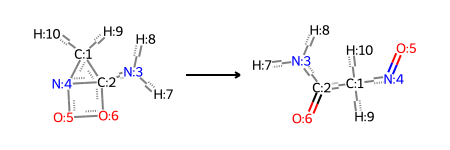

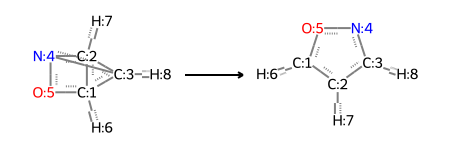

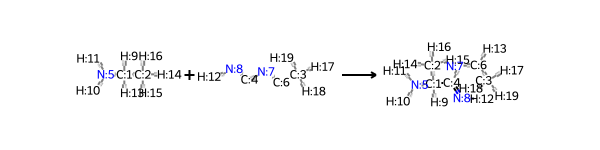

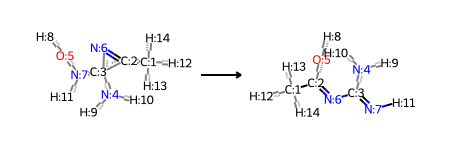

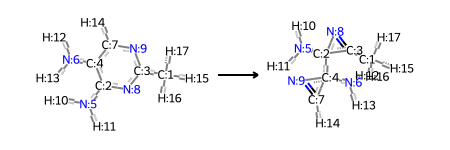

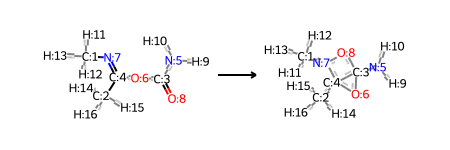

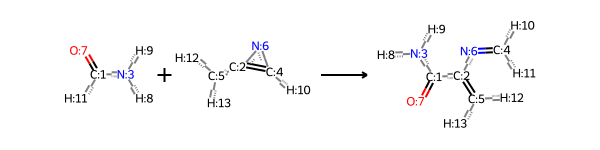

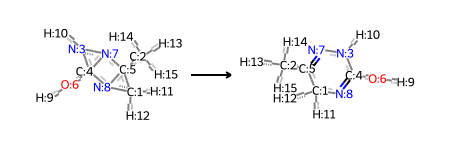

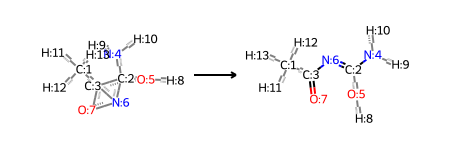

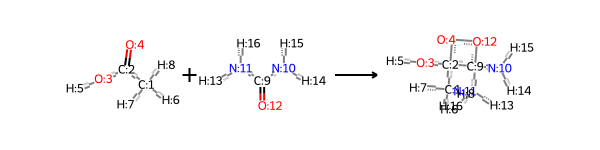

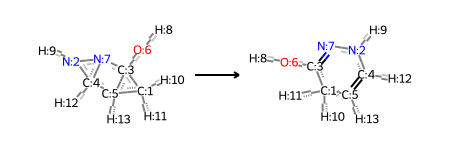

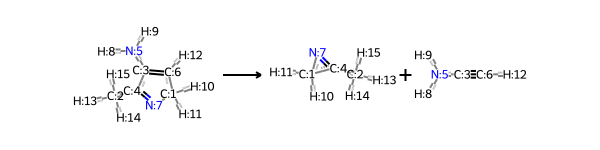

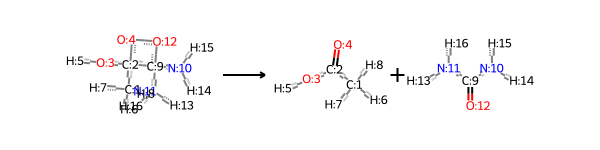

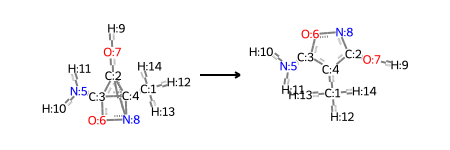

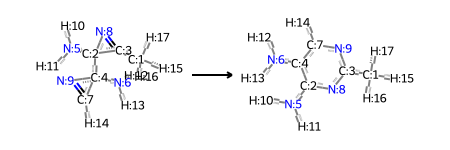

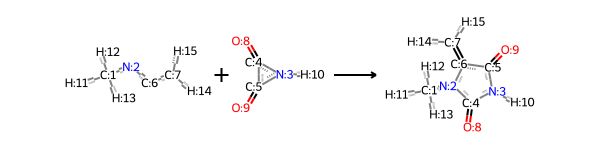

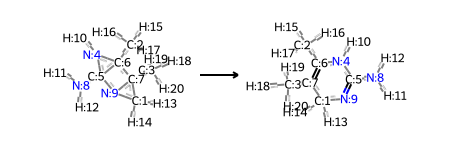

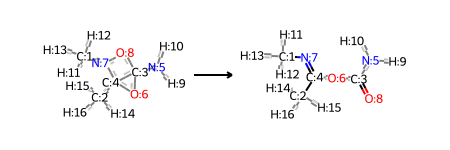

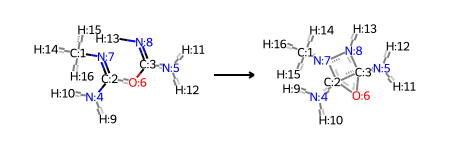

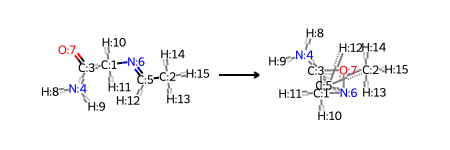

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdChemReactions

preds_rgd1 = pd.read_csv("/home/akshatz/bond_order_free/barriers_rgd1/run1_bof/results/model_0/test_predictions.csv")
preds_rgd1 = preds_rgd1.sort_values(by='ea', ascending=False)
# display(preds_rgd1)
# smi1 = preds_rgd1.iloc[0]['smiles']
# smi2 = preds_rgd1.iloc[1]['smiles']
# smi1

smi_lst1 = [preds_rgd1.loc[i]['smiles'] for i in smi_lst]
reaction_lst1 = [rdChemReactions.ReactionFromSmarts(smi) for smi in smi_lst1]
[display(reaction) for reaction in reaction_lst1]
# smi1 = preds_rgd1.loc[11159]['smiles']
# smi2 = preds_rgd1.loc[32524]['smiles']
# smi3 = preds_rgd1.loc[24719]['smiles']
# reaction1 = rdChemReactions.ReactionFromSmarts(smi1)
# reaction2 = rdChemReactions.ReactionFromSmarts(smi2)
# reaction3 = rdChemReactions.ReactionFromSmarts(smi3)
# display(reaction1)
# display(reaction2)
# display(reaction3)

In [ ]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# from rdkit.Chem import rdChemReactions

# preds_rgd1 = pd.read_csv("/home/akshatz/bond_order_free/barriers_rgd1/run1_baseline/model_0/test_predictions.csv")
# preds_rgd1 = preds_rgd1.sort_values(by='ea', ascending=False)
# preds_rgd1
# smi1 = preds_rgd1.iloc[0]['smiles']
# smi2 = preds_rgd1.iloc[1]['smiles']
# smi1

# reaction1 = rdChemReactions.ReactionFromSmarts(smi1)
# reaction2 = rdChemReactions.ReactionFromSmarts(smi2)
# display(reaction1)
# display(reaction2)

reactant


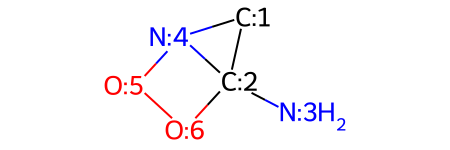

product


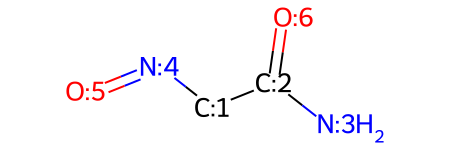

done
reactant


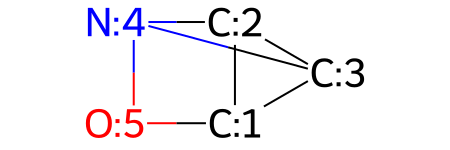

product


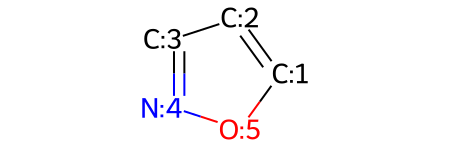

done
reactant


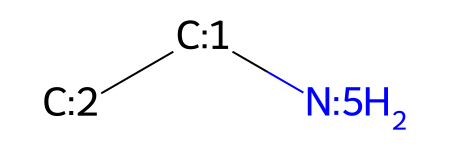

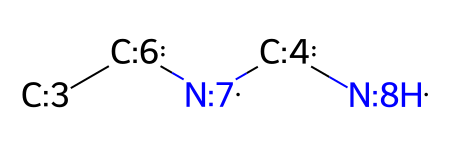

product


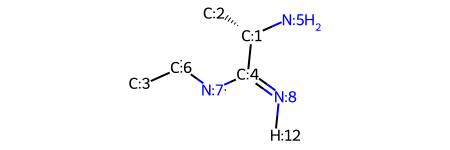

done
reactant


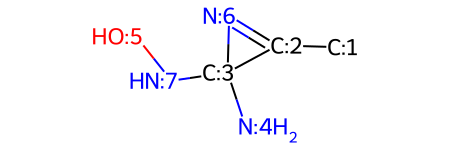

product


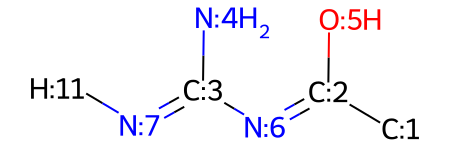

done
reactant


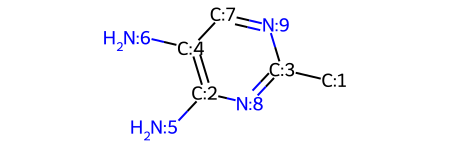

product


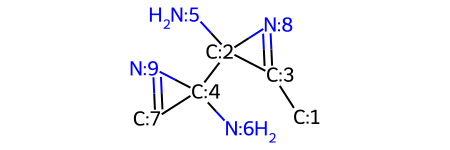

done
reactant


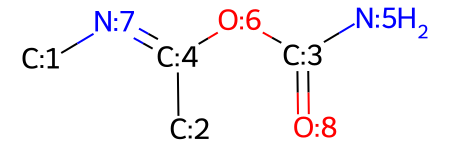

product


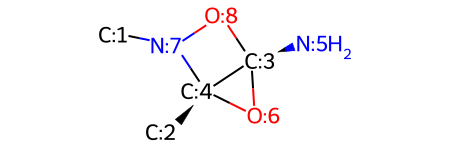

done
reactant


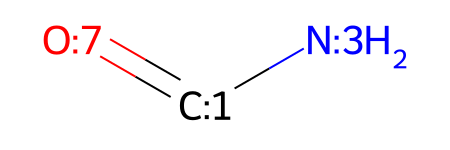

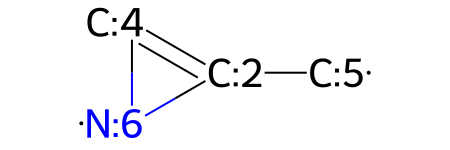

product


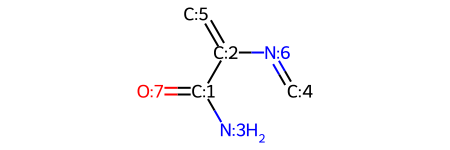

done
reactant


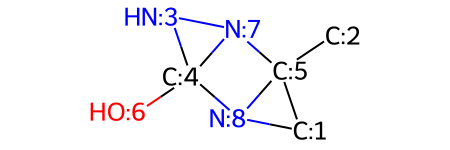

product


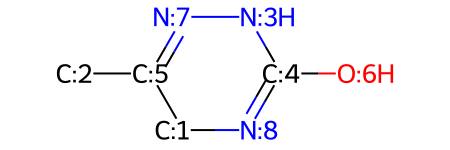

done
reactant


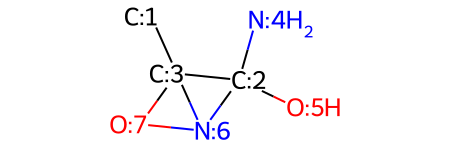

product


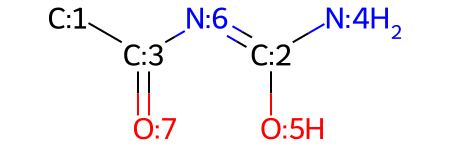

done
reactant


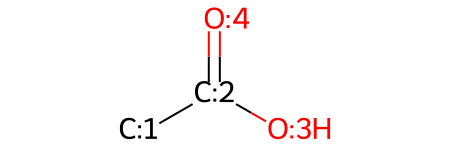

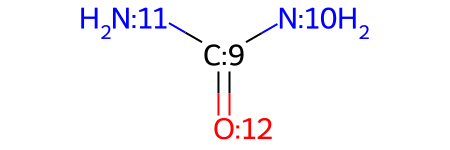

product


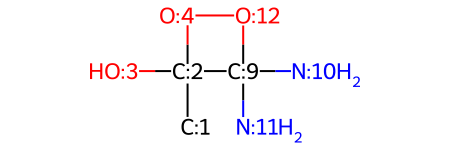

done
reactant


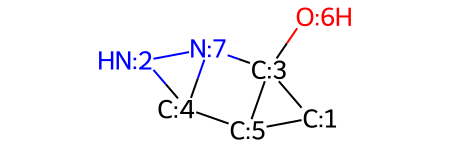

product


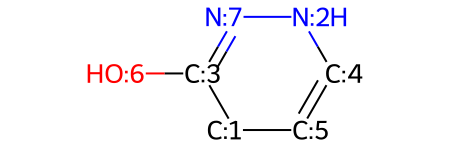

done
reactant


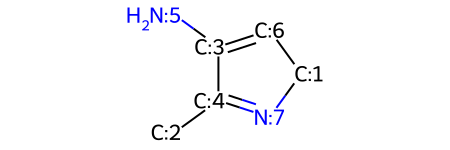

product


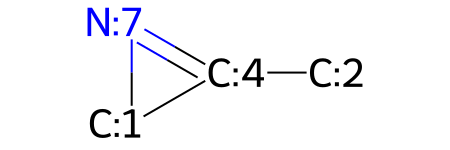

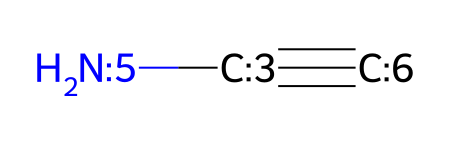

done
reactant


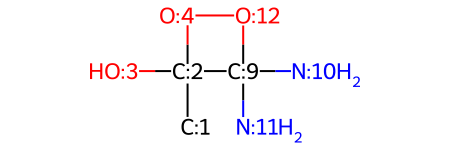

product


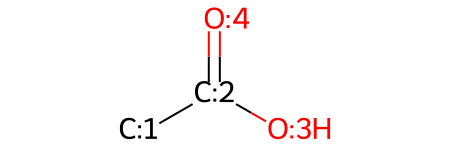

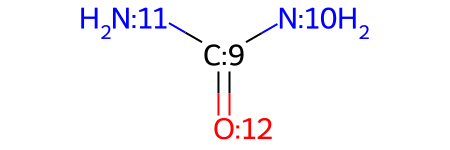

done
reactant


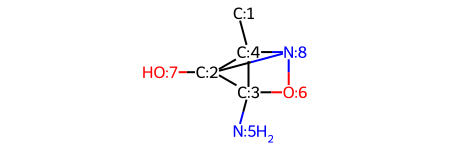

product


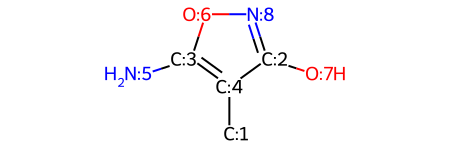

done
reactant


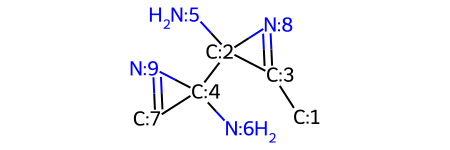

product


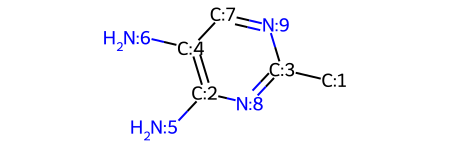

done
reactant


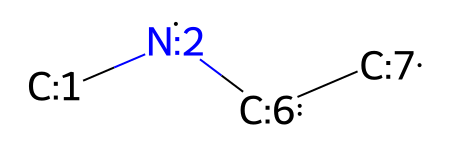

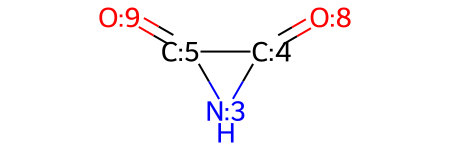

product


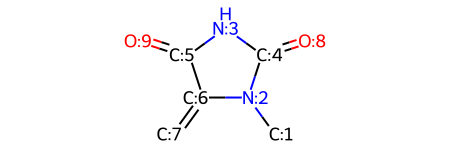

done
reactant


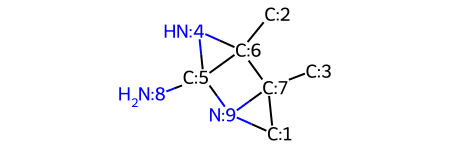

product


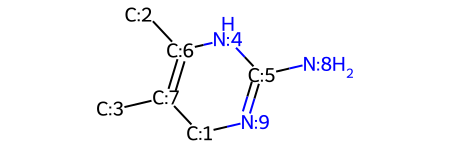

done
reactant


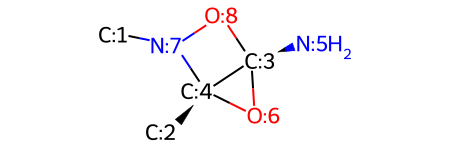

product


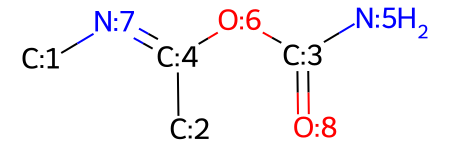

done
reactant


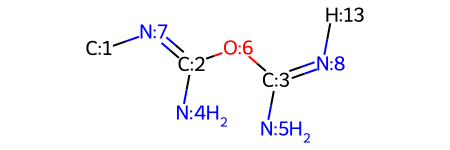

product


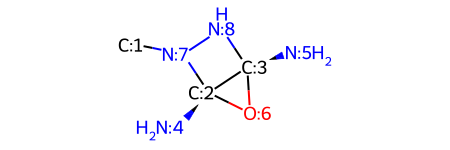

done
reactant


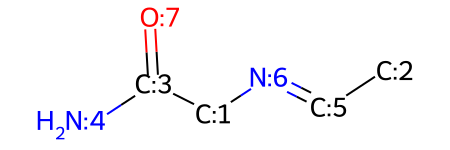

product


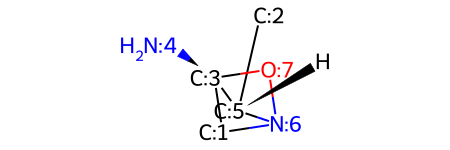

done


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display  # For displaying images in Jupyter or similar

for smi in smi_lst1:
    reaction_smiles = smi

    reactants_smiles, products_smiles = reaction_smiles.split(">>")
    reactants = [Chem.MolFromSmiles(smiles) for smiles in reactants_smiles.split('.')]
    products = [Chem.MolFromSmiles(smiles) for smiles in products_smiles.split('.')]
    print('reactant')
    [display(reactant) for reactant in reactants]
    print('product')
    [display(product) for product in products]
    print('done')


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display  # For displaying images in Jupyter or similar

# Reaction SMILES
reaction_smiles = smi2

# Split reactants and products
reactants_smiles, products_smiles = reaction_smiles.split(">>")

# Parse reactants and products
reactants = [Chem.MolFromSmiles(smiles) for smiles in reactants_smiles.split('.')]
products = [Chem.MolFromSmiles(smiles) for smiles in products_smiles.split('.')]

# Draw reactants and products
reactants_image = Draw.MolsToGridImage(reactants, subImgSize=(300, 300), legends=["Reactant"])
products_image = Draw.MolsToGridImage(products, subImgSize=(300, 300), legends=["Product"])

# Display images
display(reactants_image)
display(products_image)

NameError: name 'smi2' is not defined

In [ ]:
data_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/rgd1_data.csv"
splits_path = "/home/akshatz/bond_order_free/barriers_rgd1/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/barriers_rgd1/run1_bof/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results_err(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
mean,[8.484378203701606],[12.693906473065327],[0.8176949774166007]
std,[0.011468758736818893],[0.02637106528897728],[0.0007572956129974668]


# HIV

### Chemprop (without -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/hiv/dataset/hiv_data.csv"
splits_path = "/home/akshatz/bond_order_free/hiv/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/hiv/run1_baseline"
num_tasks = 1
metrics = ["roc-auc", "ap", "prc-auc"]
results = evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["HIV_active"])
display(results)

,roc-auc,ap,prc-auc
HIV_active,0.771332,0.306667,0.30476


### RIGR (wihout -h)

In [ ]:
data_path = "/home/akshatz/bond_order_free/hiv/dataset/hiv_data.csv"
splits_path = "/home/akshatz/bond_order_free/hiv/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/hiv/run1_bof/results"
num_tasks = 1
metrics = ["roc-auc", "ap", "prc-auc"]
results = evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=["HIV_active"])
display(results)

,roc-auc,ap,prc-auc
HIV_active,0.804531,0.311408,0.309034


# PCBA Random

In [ ]:
def evaluate_results_with_nan_targets(data_path, splits_path, result_dir, num_tasks, metrics, target_columns=None):
    df = pd.read_csv(data_path)
    with open(splits_path, "rb") as json_file:
        split_idxss = json.load(json_file)
    test_indices = [parse_indices(d["test"]) for d in split_idxss]
    test_df = df.iloc[test_indices[0]]
    target_columns=test_df.keys()[-num_tasks:].tolist() if target_columns is None else target_columns

    df_pred_list = []
    files = glob.glob(os.path.join(result_dir, '**', "test_predictions.csv"), recursive=True)
    assert len(files) == 5, f"There should be 5 files; {len(files)} found"
    for file in files:
        df_pred = pd.read_csv(file)[target_columns]
        df_pred_list.append(df_pred)
    df_pred = pd.concat(df_pred_list).groupby(level=0).mean()

    metric_to_func = {metric: get_metric_func(metric) for metric in metrics}

    results = defaultdict(list)
    for column in target_columns:
        for metric, metric_func in metric_to_func.items():
            preds = df_pred[column].tolist()
            # targets = test_df[column].fillna(0.0).tolist()
            targets = test_df[column].tolist()
            
            pairs = [(target, pred) for target, pred in zip(targets, preds) if not np.isnan(target)]
            targets = [item[0] for item in pairs]
            preds = [item[1] for item in pairs]
            
            results[metric].append(metric_func(targets, preds))
    results = dict(results)

    results_df = pd.DataFrame(results, index=target_columns)
    return results_df

In [ ]:
data_path = "/home/akshatz/bond_order_free/pcba_random/dataset/pcba_random_data.csv"
splits_path = "/home/akshatz/bond_order_free/pcba_random/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/pcba_random/run1_bof_wo_h/results"
num_tasks = 128
metrics = ["prc-auc", "ap", "roc-auc"]
evaluate_results_with_nan_targets(data_path, splits_path, result_dir, num_tasks, metrics).mean()

prc-auc    0.206780
ap         0.212728
roc-auc    0.902725
dtype: float64

# PCBA Random NaN

In [ ]:
data_path = "/home/akshatz/bond_order_free/pcba_random_nan/dataset/pcba_random_nan_data.csv"
splits_path = "/home/akshatz/bond_order_free/pcba_random_nan/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/pcba_random_nan/run1_bof_wo_h/results"
num_tasks = 128
metrics = ["prc-auc", "ap", "roc-auc"]
evaluate_results_with_nan_targets(data_path, splits_path, result_dir, num_tasks, metrics).mean()

prc-auc    0.370045
ap         0.376932
roc-auc    0.904345
dtype: float64

# PCBA Scaffold

In [ ]:
data_path = "/home/akshatz/bond_order_free/pcba_scaffold/dataset/pcba_scaffold_data.csv"  # setting NaN targets to 0
splits_path = "/home/akshatz/bond_order_free/pcba_scaffold/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/pcba_scaffold/run1_bof_wo_h/results"
num_tasks = 127
metrics = ["prc-auc", "ap", "roc-auc"]
evaluate_results_with_nan_targets(data_path, splits_path, result_dir, num_tasks, metrics).mean()

prc-auc    0.284720
ap         0.288519
roc-auc    0.871498
dtype: float64

# PCQM4MV2

In [9]:
data_path = "/home/akshatz/bond_order_free/pcqm4mv2/dataset/pcqm4mv2_data.csv"
splits_path = "/home/akshatz/bond_order_free/pcqm4mv2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/pcqm4mv2/chemprop_benchmark_v2.0.3/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
homolumogap,0.091278,0.150996,0.98318


In [56]:
data_path = "/home/akshatz/bond_order_free/pcqm4mv2/dataset/pcqm4mv2_data.csv"
splits_path = "/home/akshatz/bond_order_free/pcqm4mv2/dataset/splits.json"
result_dir = "/home/akshatz/bond_order_free/pcqm4mv2/run1_bof/results"
num_tasks = 1
metrics = ["mae", "rmse", "r2"]
evaluate_results(data_path, splits_path, result_dir, num_tasks, metrics)

,mae,rmse,r2
homolumogap,0.094852,0.161412,0.980779


# SAMPL

In [47]:
def evaluate_sampl(test_no, result_dir, metrics):
    targets = None
    df_pred_list = []
    files = glob.glob(os.path.join(result_dir, '**', f"pred_SAMPL{test_no}.csv"), recursive=True)
    assert len(files) == 1, f"There should be 1 file; {len(files)} found"
    for file in files:
        df = pd.read_csv(file)
        
        if targets is None:
            targets = df["logP mean"].tolist() if test_no != 9 else df["new_logPexp_reviewed"].tolist()
            
        df_pred = df["pred_0"]
        df_pred_list.append(df_pred)
    preds = pd.concat(df_pred_list).groupby(level=0).mean().tolist()
    
    metric_to_func = {metric: get_metric_func(metric) for metric in metrics}

    results = defaultdict(list)
    for metric, metric_func in metric_to_func.items():
        results[metric].append(metric_func(targets, preds))
    results = dict(results)

    results_df = pd.DataFrame(results, index=[f"logP - SAMPL{test_no}"])
    return results_df

In [48]:
metrics = metrics = ["mae", "rmse", "r2"]
evaluate_sampl(6, "/home/akshatz/bond_order_free/logp/run1_bof/results_sampl_production", metrics)

,mae,rmse,r2
logP - SAMPL6,0.323174,0.391207,0.655518


In [49]:
metrics = metrics = ["mae", "rmse", "r2"]
evaluate_sampl(7, "/home/akshatz/bond_order_free/logp/run1_bof/results_sampl_production", metrics)

,mae,rmse,r2
logP - SAMPL7,0.358151,0.501945,0.428742


In [50]:
metrics = metrics = ["mae", "rmse", "r2"]
evaluate_sampl(9, "/home/akshatz/bond_order_free/logp/run1_bof/results_sampl_production", metrics)

,mae,rmse,r2
logP - SAMPL9,0.968365,1.122327,0.749068
